# 03 - Many Solitons

This notebook computes N=5, 10, 20, and 50 reflectionless KdV potentials, checks stability with conserved quantities, and contrasts the stable paired Crum algorithm with a naive Darboux chain.

In [8]:
using Pkg
Pkg.activate("..")

using Revise
includet("../src/KdVCrumProject.jl")
using .KdVCrumProject

using Plots, LaTeXStrings, BenchmarkTools

  Activating project at `~/Desktop/ResearchProjects/Dilute Gases/KdVCrumProject`


In [16]:
x = collect(range(-75.0, 75.0; step=0.05))
Ns = [50,100,110,120]

function spectrum_for_N(N)
    kappa = uniform_kappa(N; start=0.35, spacing=0.08)
    beta = alternating_norming_constants(N)
    return kappa, beta
end;

Run the stable O(N^2) algorithm and collect positivity, finiteness, and invariant-based error checks.

In [17]:
stable_results = Dict{Int, Any}()

for N in Ns
    kappa, beta = spectrum_for_N(N)
    elapsed = @elapsed q = crum_transform(x, kappa, beta)
    E1, E2 = conserved_errors(x, q, kappa)
    stable_results[N] = (kappa=kappa, beta=beta, q=q, E1=E1, E2=E2, elapsed=elapsed)
    println("N=", N,
            " finite=", all(isfinite, q),
            " min=", minimum(q),
            " max=", maximum(q),
            " E1=", E1,
            " E2=", E2,
            " elapsed=", round(elapsed; digits=3), " s")
end

N=50 finite=true min=1.0486507174766322e-13 max=18.653661707727924 E1=5.289102489314246e-13 E2=9.0427665355719e-13 elapsed=0.276 s
N=100 finite=true min=3.322286729942099e-11 max=69.12977744917394 E1=1.631856472172899e-8 E2=3.630148182054427e-8 elapsed=1.08 s
N=110 finite=true min=7.44243481742615e-11 max=83.06523637260099 E1=5.8096965571685644e-8 E2=1.0971211406030079e-7 elapsed=1.357 s
N=120 finite=true min=1.5581386343943623e-10 max=98.28550702725892 E1=2.223087986918948e-6 E2=5.034995631647554e-6 elapsed=1.558 s


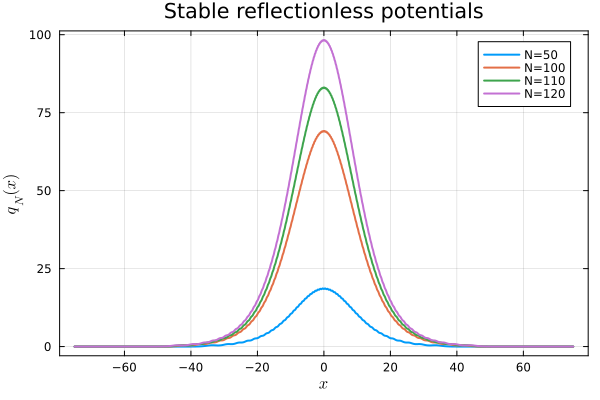

In [18]:
plt = plot(; xlabel=L"x", ylabel=L"q_N(x)", title="Stable reflectionless potentials", framestyle=:box)
for N in Ns
    plot!(plt, x, stable_results[N].q; label="N=$N", linewidth=2)
end
plt

The next cell compares with the naive Darboux chain for moderate N. For N=50 it can be slow and less informative during interactive exploration, so it is kept optional.

For larger or more tightly spaced spectra, rerun the transform in arbitrary precision. The output is a `Vector{BigFloat}`; convert only for plotting.

conserved_errors(xhp, q80, khp) = (5.562391958748664118289791210337503989558288752920532890437740243359420570440533e-07, 3.160607330741661269692073084603908248616147811410163637257034657862790841335453e-12)


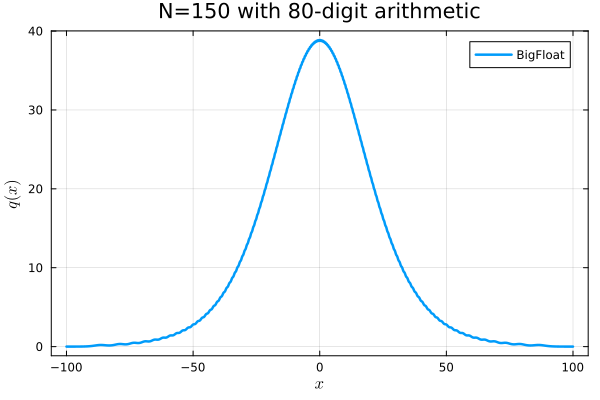

In [25]:
Nhp = 150
xhp = collect(range(-100.0, 100.0; length=5001))
khp = uniform_kappa(Nhp; start=0.25, spacing=0.04)
bhp = alternating_norming_constants(Nhp)

# q64 = crum_transform(xhp, khp, bhp)
q80 = crum_transform(xhp, khp, bhp; digits=80)

# @show eltype(q64)
# @show eltype(q80)
# @show all(isfinite, q64) all(isfinite, q80)
# @show minimum(q64) minimum(q80)
# @show conserved_errors(xhp, q64, khp)
@show conserved_errors(xhp, q80, khp)

plot_potential(Float64.(xhp), Float64.(q80); title="N=$Nhp with 80-digit arithmetic", label="BigFloat")

A compact benchmark of the stable algorithm can be run after the first pass has compiled the code.

In [15]:
Nbench = 20
kbench, bbench = spectrum_for_N(Nbench)
@benchmark crum_transform($x, $kbench, $bbench)

BenchmarkTools.Trial: 119 samples with 1 evaluation per sample.
 Range (min … max):  37.220 ms … 153.048 ms  ┊ GC (min … max):  6.83% … 76.15%
 Time  (median):     40.953 ms               ┊ GC (median):    13.20%
 Time  (mean ± σ):   42.282 ms ±  11.008 ms  ┊ GC (mean ± σ):  14.32% ±  8.19%

   ▄█  ▁  ▃▅▁                                                   
  ▆██▇▅██▆███▄▃▁▁▃▁▁▁▁▃▁▃▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃ ▃
  37.2 ms         Histogram: frequency by time         73.4 ms <

 Memory estimate: 145.33 MiB, allocs estimate: 2701127.